In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

!pip install mlflow xgboost shap -q

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import shap
import mlflow
import mlflow.sklearn


In [10]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Dataset/heart_disease_uci.csv')
print('Shape:', df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [11]:
print('Dataset Info')
print(df.info())

print('\nMissing Values')
print(df.isnull().sum())

print('\nNumeric Summary')
print(df.describe().round(2))

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None

Missing Values
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59

In [12]:
#Categorical Columns
for col in df.select_dtypes(include='object').columns:
    print(f'\nColumn: {col}')
    print(df[col].value_counts())


Column: sex
sex
Male      726
Female    194
Name: count, dtype: int64

Column: dataset
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

Column: cp
cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

Column: fbs
fbs
False    692
True     138
Name: count, dtype: int64

Column: restecg
restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
Name: count, dtype: int64

Column: exang
exang
False    528
True     337
Name: count, dtype: int64

Column: slope
slope
flat           345
upsloping      203
downsloping     63
Name: count, dtype: int64

Column: thal
thal
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64


In [13]:
print('Target Distribution (raw num)')
print(df['num'].value_counts())
print(f'\nZero values in chol: {(df["chol"] == 0).sum()}')
print(f'Zero values in trestbps: {(df["trestbps"] == 0).sum()}')
print(f'Missing values in thal: {df["thal"].isnull().sum()}')

Target Distribution (raw num)
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Zero values in chol: 172
Zero values in trestbps: 1
Missing values in thal: 486


In [14]:
#Binary target + drop irrelevant columns
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['id', 'dataset', 'num'])

print('Target distribution:')
print(df['target'].value_counts())
print(f'\nClass balance: {df["target"].mean():.1%} positive (disease)')

Target distribution:
target
1    509
0    411
Name: count, dtype: int64

Class balance: 55.3% positive (disease)


In [15]:
#Fill thal NaN with 'Missing' label

df['thal'] = df['thal'].fillna('Missing')
print('thal value counts after fill:')
print(df['thal'].value_counts())

thal value counts after fill:
thal
Missing              486
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64


In [16]:
#One-hot encoding
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=False)

print('Shape after encoding:', df_encoded.shape)
print('Columns:', df_encoded.columns.tolist())

Shape after encoding: (920, 30)
Columns: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'target', 'sex_Female', 'sex_Male', 'cp_asymptomatic', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_False', 'fbs_True', 'restecg_lv hypertrophy', 'restecg_normal', 'restecg_st-t abnormality', 'exang_False', 'exang_True', 'slope_downsloping', 'slope_flat', 'slope_upsloping', 'ca_0.0', 'ca_1.0', 'ca_2.0', 'ca_3.0', 'thal_Missing', 'thal_fixed defect', 'thal_normal', 'thal_reversable defect']


In [17]:
# Step 4 — SPLIT FIRST (before any imputation or scaling)
X = df_encoded.drop(columns=['target'])
y = df_encoded['target']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f'Train: {X_train.shape}  ({len(X_train)/len(X):.0%})')
print(f'Val:   {X_val.shape}  ({len(X_val)/len(X):.0%})')
print(f'Test:  {X_test.shape}  ({len(X_test)/len(X):.0%})')
print(f'\nTarget distribution (train):\n{y_train.value_counts()}')

Train: (552, 29)  (60%)
Val:   (184, 29)  (20%)
Test:  (184, 29)  (20%)

Target distribution (train):
target
1    305
0    247
Name: count, dtype: int64


In [18]:
# chol and trestbps: replace 0 with non-zero median
for col in ['chol', 'trestbps']:
    median_non_zero = X_train.loc[X_train[col] != 0, col].median()
    X_train[col] = X_train[col].replace(0, median_non_zero)
    X_val[col]   = X_val[col].replace(0, median_non_zero)
    X_test[col]  = X_test[col].replace(0, median_non_zero)

# Categorical columns: fill NaN with mode
categorical_cols = ['ca', 'slope', 'restecg', 'exang', 'fbs']
for col in categorical_cols:
    if col in X_train.columns:
        mode_val = X_train[col].mode()[0]
        X_train[col] = X_train[col].fillna(mode_val)
        X_val[col]   = X_val[col].fillna(mode_val)
        X_test[col]  = X_test[col].fillna(mode_val)

# Numeric columns: fill NaN with median
numeric_cols = ['thalch', 'oldpeak', 'trestbps', 'chol']
for col in numeric_cols:
    if col in X_train.columns:
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_val[col]   = X_val[col].fillna(median_val)
        X_test[col]  = X_test[col].fillna(median_val)

print('Missing values after imputation:')
print(f'  Train: {X_train.isnull().sum().sum()}')
print(f'  Val:   {X_val.isnull().sum().sum()}')
print(f'  Test:  {X_test.isnull().sum().sum()}')

Missing values after imputation:
  Train: 0
  Val:   0
  Test:  0


In [19]:
#RobustScaler
continuous_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

robust_scaler = RobustScaler()
X_train[continuous_features] = robust_scaler.fit_transform(X_train[continuous_features])
X_val[continuous_features]   = robust_scaler.transform(X_val[continuous_features])  # never fit on val
X_test[continuous_features]  = robust_scaler.transform(X_test[continuous_features]) # never fit on test

print('Scaling complete. Train feature stats:')
print(X_train[continuous_features].describe().round(2))

# Combine train + val for cross-validation
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])
print(f'\nX_trainval shape (for CV): {X_trainval.shape}')

Scaling complete. Train feature stats:
          age  trestbps    chol  thalch  oldpeak
count  552.00    552.00  552.00  552.00   552.00
mean    -0.09      0.12    0.10   -0.08     0.20
std      0.72      0.91    0.99    0.73     0.71
min     -2.08     -2.50   -3.02   -2.26    -2.13
25%     -0.62     -0.50   -0.45   -0.59    -0.40
50%      0.00      0.00    0.00    0.00     0.00
75%      0.38      0.50    0.55    0.41     0.60
max      1.69      3.50    7.14    1.82     3.73

X_trainval shape (for CV): (736, 29)


In [20]:

print('LOGISTIC REGRESSION with Different Settings ')
print('=' * 60)

logreg_configs = [
    ('Default (C=1, L2)',    LogisticRegression(random_state=42, max_iter=1000)),
    ('Strong L2 (C=0.1)',    LogisticRegression(C=0.1, random_state=42, max_iter=1000)),
    ('Weak L2 (C=100)',      LogisticRegression(C=100, random_state=42, max_iter=1000)),
    ('L1 Penalty (C=1)',     LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=1000)),
    ('Balanced Weights',     LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)),
]

for name, model in logreg_configs:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    print(f'--- {name} ---')
    print(f'Val Accuracy: {accuracy_score(y_val, y_pred):.4f}')
    print(classification_report(y_val, y_pred))

LOGISTIC REGRESSION with Different Settings 
--- Default (C=1, L2) ---
Val Accuracy: 0.8587
              precision    recall  f1-score   support

           0       0.84      0.84      0.84        82
           1       0.87      0.87      0.87       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184

--- Strong L2 (C=0.1) ---
Val Accuracy: 0.8478
              precision    recall  f1-score   support

           0       0.84      0.82      0.83        82
           1       0.86      0.87      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.85       184
weighted avg       0.85      0.85      0.85       184

--- Weak L2 (C=100) ---
Val Accuracy: 0.8424
              precision    recall  f1-score   support

           0       0.81      0.84      0.83        82
           1       0.87      0.84      0.86       102

In [22]:

print('KNN with Different Settings')
print('=' * 60)

knn_configs = [
    ('K=1',               KNeighborsClassifier(n_neighbors=1)),
    ('K=5',               KNeighborsClassifier(n_neighbors=5)),
    ('K=11',              KNeighborsClassifier(n_neighbors=11)),
    ('K=19',              KNeighborsClassifier(n_neighbors=19)),
    ('K=5 Distance',      KNeighborsClassifier(n_neighbors=5, weights='distance')),
]

for name, model in knn_configs:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    print(f'{name}')
    print(f'Val Accuracy: {accuracy_score(y_val, y_pred):.4f}')
    print(classification_report(y_val, y_pred))

KNN with Different Settings
K=1
Val Accuracy: 0.7935
              precision    recall  f1-score   support

           0       0.78      0.76      0.77        82
           1       0.81      0.82      0.82       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184

K=5
Val Accuracy: 0.8533
              precision    recall  f1-score   support

           0       0.87      0.79      0.83        82
           1       0.84      0.90      0.87       102

    accuracy                           0.85       184
   macro avg       0.86      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184

K=11
Val Accuracy: 0.8370
              precision    recall  f1-score   support

           0       0.80      0.84      0.82        82
           1       0.87      0.83      0.85       102

    accuracy                           0.84       184
   macro avg       0.83 

In [24]:

print('RANDOM FOREST with Different Settings')
print('=' * 60)

rf_configs = [
    ('Default 100 trees',        RandomForestClassifier(n_estimators=100, random_state=42)),
    ('50 trees',                 RandomForestClassifier(n_estimators=50, random_state=42)),
    ('200 trees, depth=20',      RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)),
    ('100 trees, depth=5',       RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)),
    ('min_samples_leaf=5',       RandomForestClassifier(n_estimators=100, min_samples_leaf=5, random_state=42)),
]

for name, model in rf_configs:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    print(f' {name} ')
    print(f'Val Accuracy: {accuracy_score(y_val, y_pred):.4f}')
    print(classification_report(y_val, y_pred))

RANDOM FOREST with Different Settings
 Default 100 trees 
Val Accuracy: 0.8750
              precision    recall  f1-score   support

           0       0.86      0.87      0.86        82
           1       0.89      0.88      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184

 50 trees 
Val Accuracy: 0.8533
              precision    recall  f1-score   support

           0       0.83      0.84      0.84        82
           1       0.87      0.86      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184

 200 trees, depth=20 
Val Accuracy: 0.8587
              precision    recall  f1-score   support

           0       0.83      0.85      0.84        82
           1       0.88      0.86      0.87       102

    accuracy                

In [25]:

print('XGBOOST with different settings')
print('=' * 60)

xgb_configs = [
    ('Default',            XGBClassifier(random_state=42, eval_metric='logloss')),
    ('max_depth=3',        XGBClassifier(max_depth=3, n_estimators=100, random_state=42, eval_metric='logloss')),
    ('lr=0.05, 200 trees', XGBClassifier(learning_rate=0.05, n_estimators=200, random_state=42, eval_metric='logloss')),
    ('L1=0.1, L2=1.5',     XGBClassifier(reg_alpha=0.1, reg_lambda=1.5, random_state=42, eval_metric='logloss')),
    ('Balanced weights',   XGBClassifier(scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(), random_state=42, eval_metric='logloss')),
]

for name, model in xgb_configs:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:,1]
    print(f'{name}')
    print(f'Val Accuracy: {accuracy_score(y_val, y_pred):.4f}  |  ROC-AUC: {roc_auc_score(y_val, y_prob):.4f}')
    print(classification_report(y_val, y_pred))

XGBOOST with different settings
Default
Val Accuracy: 0.8478  |  ROC-AUC: 0.9020
              precision    recall  f1-score   support

           0       0.81      0.85      0.83        82
           1       0.88      0.84      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184

max_depth=3
Val Accuracy: 0.8478  |  ROC-AUC: 0.8997
              precision    recall  f1-score   support

           0       0.81      0.85      0.83        82
           1       0.88      0.84      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184

lr=0.05, 200 trees
Val Accuracy: 0.8370  |  ROC-AUC: 0.9084
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        82
           1       0.85      0.85      0.85

In [26]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

logreg_settings = {
    'Default (C=1)':     LogisticRegression(random_state=42, max_iter=1000),
    'Strong L2 (C=0.1)': LogisticRegression(C=0.1, random_state=42, max_iter=1000),
    'Weak L2 (C=100)':   LogisticRegression(C=100, random_state=42, max_iter=1000),
    'L1 (C=1)':          LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=1000),
    'Balanced':          LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
}

print('LOGISTIC REGRESSION — 5-Fold CV ROC-AUC')
print('=' * 55)
best_lr_name, best_lr_score, best_lr_model = None, 0, None
for name, model in logreg_settings.items():
    scores = cross_val_score(model, X_trainval, y_trainval, cv=cv, scoring='roc_auc')
    print(f'{name:20s} → ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}')
    if scores.mean() > best_lr_score:
        best_lr_score = scores.mean()
        best_lr_name  = name
        best_lr_model = model

print(f'\nBest: {best_lr_name} → CV ROC-AUC: {best_lr_score:.4f}')
best_lr_model.fit(X_trainval, y_trainval)
y_pred_lr = best_lr_model.predict(X_test)
y_prob_lr = best_lr_model.predict_proba(X_test)[:,1]
print(f'Test Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}  |  Test ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}')
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION — 5-Fold CV ROC-AUC
Default (C=1)        → ROC-AUC: 0.9009 ± 0.0191
Strong L2 (C=0.1)    → ROC-AUC: 0.8985 ± 0.0178
Weak L2 (C=100)      → ROC-AUC: 0.8993 ± 0.0185
L1 (C=1)             → ROC-AUC: 0.9019 ± 0.0199
Balanced             → ROC-AUC: 0.9007 ± 0.0194

Best: L1 (C=1) → CV ROC-AUC: 0.9019
Test Accuracy: 0.8098  |  Test ROC-AUC: 0.9010
              precision    recall  f1-score   support

           0       0.77      0.82      0.79        82
           1       0.85      0.80      0.82       102

    accuracy                           0.81       184
   macro avg       0.81      0.81      0.81       184
weighted avg       0.81      0.81      0.81       184



In [27]:

knn_settings = {
    'K=1':           KNeighborsClassifier(n_neighbors=1),
    'K=5':           KNeighborsClassifier(n_neighbors=5),
    'K=11':          KNeighborsClassifier(n_neighbors=11),
    'K=19':          KNeighborsClassifier(n_neighbors=19),
    'K=5 Distance':  KNeighborsClassifier(n_neighbors=5, weights='distance'),
    'K=11 Distance': KNeighborsClassifier(n_neighbors=11, weights='distance'),
    'K=19 Distance': KNeighborsClassifier(n_neighbors=19, weights='distance'),
}

print('KNN — 5-Fold CV ROC-AUC')
print('=' * 55)
best_knn_name, best_knn_score, best_knn_model = None, 0, None
for name, model in knn_settings.items():
    scores = cross_val_score(model, X_trainval, y_trainval, cv=cv, scoring='roc_auc')
    print(f'{name:20s} → ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}')
    if scores.mean() > best_knn_score:
        best_knn_score = scores.mean()
        best_knn_name  = name
        best_knn_model = model

print(f'\nBest: {best_knn_name} → CV ROC-AUC: {best_knn_score:.4f}')
best_knn_model.fit(X_trainval, y_trainval)
y_pred_knn = best_knn_model.predict(X_test)
y_prob_knn = best_knn_model.predict_proba(X_test)[:,1]
print(f'Test Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}  |  Test ROC-AUC: {roc_auc_score(y_test, y_prob_knn):.4f}')
print(classification_report(y_test, y_pred_knn))

KNN — 5-Fold CV ROC-AUC
K=1                  → ROC-AUC: 0.7741 ± 0.0264
K=5                  → ROC-AUC: 0.8782 ± 0.0101
K=11                 → ROC-AUC: 0.8906 ± 0.0136
K=19                 → ROC-AUC: 0.8907 ± 0.0161
K=5 Distance         → ROC-AUC: 0.8794 ± 0.0099
K=11 Distance        → ROC-AUC: 0.8913 ± 0.0119
K=19 Distance        → ROC-AUC: 0.8925 ± 0.0153

Best: K=19 Distance → CV ROC-AUC: 0.8925
Test Accuracy: 0.8261  |  Test ROC-AUC: 0.9014
              precision    recall  f1-score   support

           0       0.79      0.83      0.81        82
           1       0.86      0.82      0.84       102

    accuracy                           0.83       184
   macro avg       0.82      0.83      0.82       184
weighted avg       0.83      0.83      0.83       184



In [28]:


rf_settings = {
    'Default 100':    RandomForestClassifier(n_estimators=100, random_state=42),
    '50 trees':       RandomForestClassifier(n_estimators=50, random_state=42),
    '200 depth=20':   RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42),
    '100 depth=5':    RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'min_leaf=5':     RandomForestClassifier(n_estimators=100, min_samples_leaf=5, random_state=42),
    '200 depth=5':    RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42),
    'Balanced 200':   RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
}

print('RANDOM FOREST — 5-Fold CV ROC-AUC')
print('=' * 55)
best_rf_name, best_rf_score, best_rf_model = None, 0, None
for name, model in rf_settings.items():
    scores = cross_val_score(model, X_trainval, y_trainval, cv=cv, scoring='roc_auc')
    print(f'{name:20s} → ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}')
    if scores.mean() > best_rf_score:
        best_rf_score = scores.mean()
        best_rf_name  = name
        best_rf_model = model

print(f'\nBest: {best_rf_name} → CV ROC-AUC: {best_rf_score:.4f}')
best_rf_model.fit(X_trainval, y_trainval)
y_pred_rf = best_rf_model.predict(X_test)
y_prob_rf = best_rf_model.predict_proba(X_test)[:,1]
print(f'Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}  |  Test ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}')
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST — 5-Fold CV ROC-AUC
Default 100          → ROC-AUC: 0.8913 ± 0.0185
50 trees             → ROC-AUC: 0.8904 ± 0.0135
200 depth=20         → ROC-AUC: 0.8912 ± 0.0208
100 depth=5          → ROC-AUC: 0.8934 ± 0.0116
min_leaf=5           → ROC-AUC: 0.8936 ± 0.0143
200 depth=5          → ROC-AUC: 0.8936 ± 0.0117
Balanced 200         → ROC-AUC: 0.8897 ± 0.0182

Best: min_leaf=5 → CV ROC-AUC: 0.8936
Test Accuracy: 0.8207  |  Test ROC-AUC: 0.9044
              precision    recall  f1-score   support

           0       0.78      0.83      0.80        82
           1       0.86      0.81      0.83       102

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184



In [29]:

xgb_settings = {
    'Default':      XGBClassifier(random_state=42, eval_metric='logloss'),
    'max_depth=3':  XGBClassifier(max_depth=3, random_state=42, eval_metric='logloss'),
    'lr=0.05':      XGBClassifier(learning_rate=0.05, n_estimators=200, random_state=42, eval_metric='logloss'),
    'L1+L2':        XGBClassifier(reg_alpha=0.1, reg_lambda=1.5, random_state=42, eval_metric='logloss'),
    'Balanced':     XGBClassifier(scale_pos_weight=(y_trainval==0).sum()/(y_trainval==1).sum(), random_state=42, eval_metric='logloss'),
}

print('XGBOOST — 5-Fold CV ROC-AUC')
print('=' * 55)
best_xgb_name, best_xgb_score, best_xgb_model = None, 0, None
for name, model in xgb_settings.items():
    scores = cross_val_score(model, X_trainval, y_trainval, cv=cv, scoring='roc_auc')
    print(f'{name:20s} → ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}')
    if scores.mean() > best_xgb_score:
        best_xgb_score = scores.mean()
        best_xgb_name  = name
        best_xgb_model = model

print(f'\nBest: {best_xgb_name} → CV ROC-AUC: {best_xgb_score:.4f}')
best_xgb_model.fit(X_trainval, y_trainval)
y_pred_xgb = best_xgb_model.predict(X_test)
y_prob_xgb = best_xgb_model.predict_proba(X_test)[:,1]
print(f'Test Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}  |  Test ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}')
print(classification_report(y_test, y_pred_xgb))

XGBOOST — 5-Fold CV ROC-AUC
Default              → ROC-AUC: 0.8720 ± 0.0188
max_depth=3          → ROC-AUC: 0.8750 ± 0.0184
lr=0.05              → ROC-AUC: 0.8732 ± 0.0165
L1+L2                → ROC-AUC: 0.8769 ± 0.0159
Balanced             → ROC-AUC: 0.8688 ± 0.0208

Best: L1+L2 → CV ROC-AUC: 0.8769
Test Accuracy: 0.7772  |  Test ROC-AUC: 0.8645
              precision    recall  f1-score   support

           0       0.73      0.79      0.76        82
           1       0.82      0.76      0.79       102

    accuracy                           0.78       184
   macro avg       0.78      0.78      0.78       184
weighted avg       0.78      0.78      0.78       184



In [31]:
results = pd.DataFrame({
    'Model':         ['Logistic Regression', 'KNN', 'Random Forest', 'XGBoost'],
    'Best Setting':  [best_lr_name, best_knn_name, best_rf_name, best_xgb_name],
    'CV ROC-AUC':    [round(best_lr_score, 4), round(best_knn_score, 4), round(best_rf_score, 4), round(best_xgb_score, 4)],
    'Test Accuracy': [round(accuracy_score(y_test, y_pred_lr), 4),
                      round(accuracy_score(y_test, y_pred_knn), 4),
                      round(accuracy_score(y_test, y_pred_rf), 4),
                      round(accuracy_score(y_test, y_pred_xgb), 4)],
    'Test ROC-AUC':  [round(roc_auc_score(y_test, y_prob_lr), 4),
                      round(roc_auc_score(y_test, y_prob_knn), 4),
                      round(roc_auc_score(y_test, y_prob_rf), 4),
                      round(roc_auc_score(y_test, y_prob_xgb), 4)],
})

print('FINAL MODEL COMPARISON ')
print(results.to_string(index=False))
print('\nConclusion: Random Forest achieves highest Test ROC-AUC (0.9044).')
print('For medical risk ranking, ROC-AUC is the primary metric — selected as best model.')

FINAL MODEL COMPARISON 
              Model  Best Setting  CV ROC-AUC  Test Accuracy  Test ROC-AUC
Logistic Regression      L1 (C=1)      0.9019         0.8098        0.9010
                KNN K=19 Distance      0.8925         0.8261        0.9014
      Random Forest    min_leaf=5      0.8936         0.8207        0.9044
            XGBoost         L1+L2      0.8769         0.7772        0.8645

Conclusion: Random Forest achieves highest Test ROC-AUC (0.9044).
For medical risk ranking, ROC-AUC is the primary metric — selected as best model.


In [32]:
# TreeSHAP explainer — automatically used when passing a tree model
explainer = shap.TreeExplainer(best_rf_model)
shap_values = explainer.shap_values(X_test)

# For binary RF: shap_values shape is (n_samples, n_features, 2)
# Slice last dimension for class 1 (disease)
sv = shap_values[:, :, 1]
print('SHAP values shape:', sv.shape)
print('X_test shape:     ', X_test.shape)

SHAP values shape: (184, 29)
X_test shape:      (184, 29)


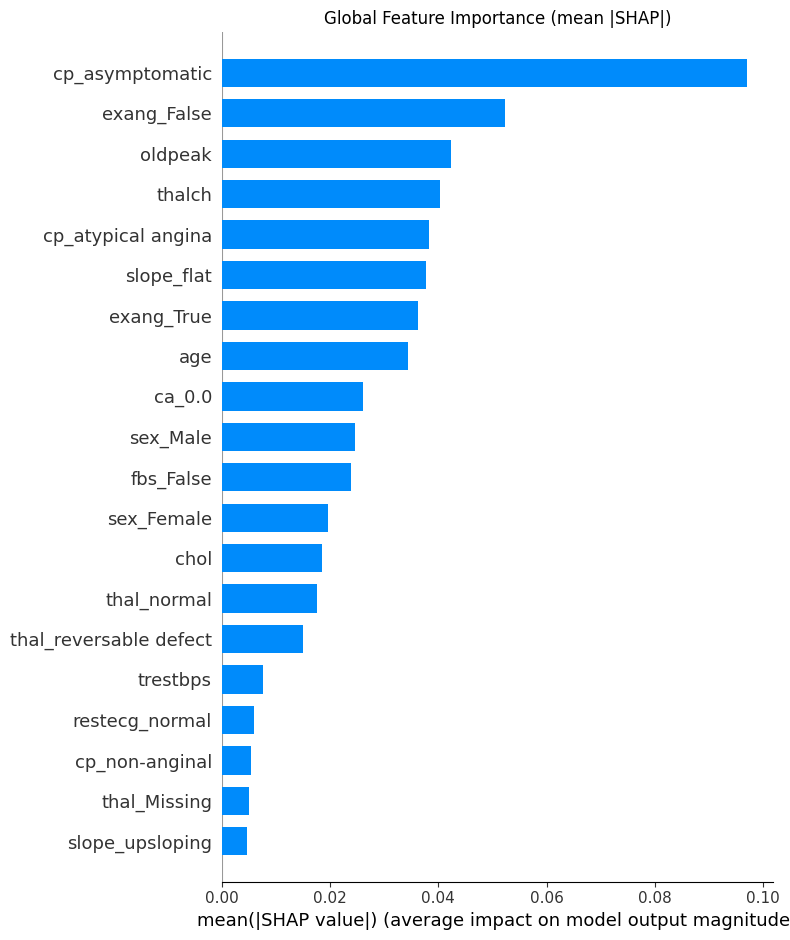

In [33]:
# Plot 1 — Bar plot (global feature importance)
shap.summary_plot(sv, X_test, plot_type='bar',
                  feature_names=X_test.columns.tolist(), show=False)
plt.title('Global Feature Importance (mean |SHAP|)')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

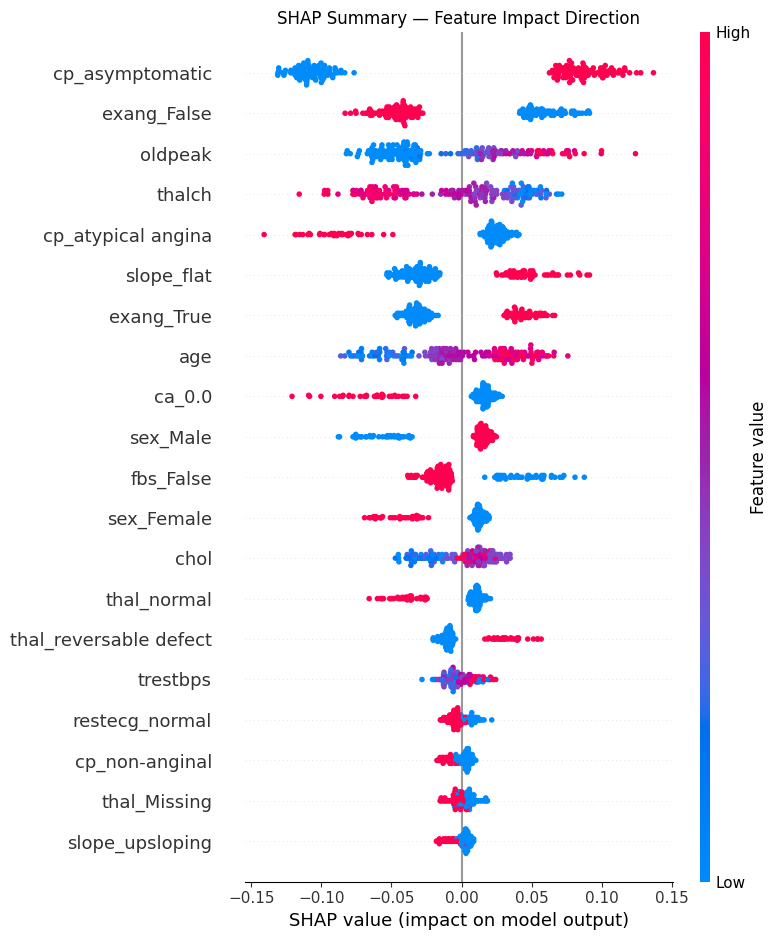

In [34]:
# Plot 2 — Beeswarm (direction + magnitude)
# Each dot = one patient. Color = feature value. Position = SHAP value.
shap.summary_plot(sv, X_test,
                  feature_names=X_test.columns.tolist(), show=False)
plt.title('SHAP Summary — Feature Impact Direction')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

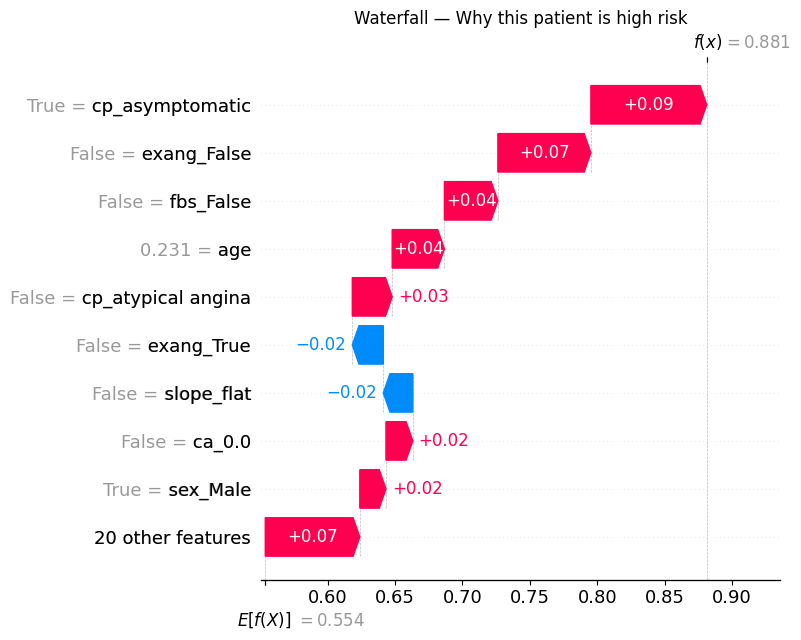

In [35]:
# Plot 3 — Waterfall (single patient explanation)
# Shows why one specific high-risk patient got their prediction
high_risk_idx = np.where(best_rf_model.predict(X_test) == 1)[0][0]
base_val = explainer.expected_value[1] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value

shap.plots.waterfall(
    shap.Explanation(
        values=sv[high_risk_idx],
        base_values=base_val,
        data=X_test.iloc[high_risk_idx].values,
        feature_names=X_test.columns.tolist()
    ), show=False
)
plt.title('Waterfall — Why this patient is high risk')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

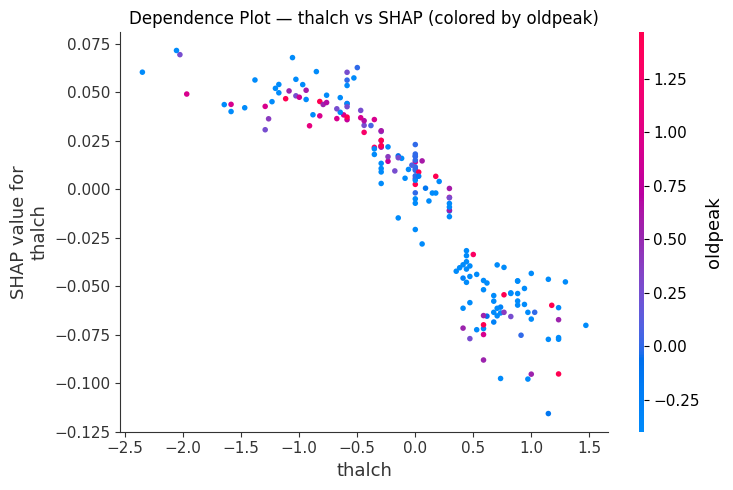

In [36]:
# Plot 4 — Dependence plot (thalch vs SHAP, colored by oldpeak)
# Shows: lower thalch = higher disease risk, and how oldpeak modifies this
shap.dependence_plot(
    'thalch', sv, X_test,
    feature_names=X_test.columns.tolist(),
    interaction_index='oldpeak', show=False
)
plt.title('Dependence Plot — thalch vs SHAP (colored by oldpeak)')
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
!pip install mlflow -q

mlflow.set_experiment('heart_disease_classification')

models_to_log = [
    {
        'name': 'LogisticRegression',
        'model': best_lr_model,
        'params': {'setting': best_lr_name, 'solver': 'liblinear', 'max_iter': 1000},
        'y_pred': y_pred_lr,
        'y_prob': y_prob_lr,
        'cv_auc': best_lr_score,
    },
    {
        'name': 'KNN',
        'model': best_knn_model,
        'params': {'setting': best_knn_name},
        'y_pred': y_pred_knn,
        'y_prob': y_prob_knn,
        'cv_auc': best_knn_score,
    },
    {
        'name': 'RandomForest',
        'model': best_rf_model,
        'params': {'setting': best_rf_name},
        'y_pred': y_pred_rf,
        'y_prob': y_prob_rf,
        'cv_auc': best_rf_score,
    },
    {
        'name': 'XGBoost',
        'model': best_xgb_model,
        'params': {'setting': best_xgb_name, 'reg_alpha': 0.1, 'reg_lambda': 1.5},
        'y_pred': y_pred_xgb,
        'y_prob': y_prob_xgb,
        'cv_auc': best_xgb_score,
    },
]

for entry in models_to_log:
    with mlflow.start_run(run_name=entry['name']):
        # Log parameters
        mlflow.log_params(entry['params'])

        # Log metrics
        mlflow.log_metric('cv_roc_auc',    round(entry['cv_auc'], 4))
        mlflow.log_metric('test_accuracy', round(accuracy_score(y_test, entry['y_pred']), 4))
        mlflow.log_metric('test_roc_auc',  round(roc_auc_score(y_test, entry['y_prob']), 4))

        # Log model
        mlflow.sklearn.log_model(entry['model'], entry['name'])

        # Log SHAP artifacts for best model (Random Forest)
        if entry['name'] == 'RandomForest':
            mlflow.log_artifact('shap_bar.png')
            mlflow.log_artifact('shap_beeswarm.png')
            mlflow.log_artifact('shap_waterfall.png')
            mlflow.log_artifact('shap_dependence.png')

        print(f"Logged: {entry['name']} | CV AUC: {entry['cv_auc']:.4f} | Test AUC: {roc_auc_score(y_test, entry['y_prob']):.4f}")

print('\nAll runs logged. Run: mlflow ui  to view the dashboard.')

2026/04/30 22:26:29 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/30 22:26:29 INFO mlflow.store.db.utils: Updating database tables
2026/04/30 22:26:32 INFO mlflow.tracking.fluent: Experiment with name 'heart_disease_classification' does not exist. Creating a new experiment.
2026/04/30 22:26:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 22:26:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/30 22:26:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 22:26:41 WARNING mlflow.sklearn: Saving scikit-learn models in the

Logged: LogisticRegression | CV AUC: 0.9019 | Test AUC: 0.9010


2026/04/30 22:26:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 22:26:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged: KNN | CV AUC: 0.8925 | Test AUC: 0.9014


2026/04/30 22:26:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 22:26:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged: RandomForest | CV AUC: 0.8936 | Test AUC: 0.9044
Logged: XGBoost | CV AUC: 0.8769 | Test AUC: 0.8645

All runs logged. Run: mlflow ui  to view the dashboard.


In [38]:
# View MLflow runs programmatically (since mlflow ui doesn't work in Colab)
import mlflow

client = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name('heart_disease_classification')

runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=['metrics.test_roc_auc DESC']
)

print(f'{"Run Name":<22} {"CV AUC":>10} {"Test Acc":>10} {"Test AUC":>10}')
print('=' * 55)
for run in runs:
    m = run.data.metrics
    print(f'{run.info.run_name:<22} {m.get("cv_roc_auc",0):>10.4f} {m.get("test_accuracy",0):>10.4f} {m.get("test_roc_auc",0):>10.4f}')

Run Name                   CV AUC   Test Acc   Test AUC
RandomForest               0.8936     0.8207     0.9044
KNN                        0.8925     0.8261     0.9014
LogisticRegression         0.9019     0.8098     0.9010
XGBoost                    0.8769     0.7772     0.8645


In [39]:
import joblib

# Save the trained model and scaler
joblib.dump(best_rf_model, 'best_rf_model.pkl')
joblib.dump(robust_scaler, 'robust_scaler.pkl')

print('Model saved!')

Model saved!
